# ch225 — Differential Equations

A differential equation (DE) is an equation that relates a function to its own derivatives. Instead of asking "what is the value of f?", it asks "how does f change?" — and the answer is a function.

Nearly every dynamical system in physics, biology, economics, and ML can be described by a differential equation.

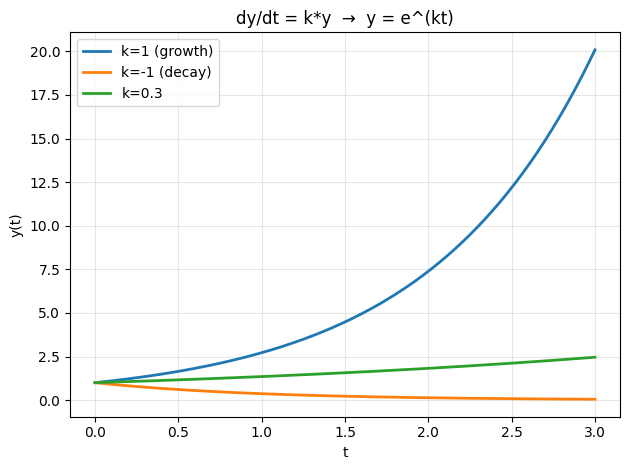

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ── Simplest ODE: exponential growth/decay ────────────────────────────────
# dy/dt = k*y,   solution: y(t) = y0 * exp(k*t)

t = np.linspace(0, 3, 200)
for k, label in [(1, 'k=1 (growth)'), (-1, 'k=-1 (decay)'), (0.3, 'k=0.3')]:
    y = np.exp(k * t)
    plt.plot(t, y, lw=2, label=label)

plt.xlabel('t'); plt.ylabel('y(t)')
plt.title('dy/dt = k*y  →  y = e^(kt)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('ch225_ode_simple.png', dpi=100); plt.show()


## Euler's Method — Numerical ODE Solving

If we can't find an analytic solution, we step forward numerically. Euler's method approximates `y(t+h) ≈ y(t) + h * f(t, y)`.

This is integration *(ch221)* of the derivative, one step at a time.

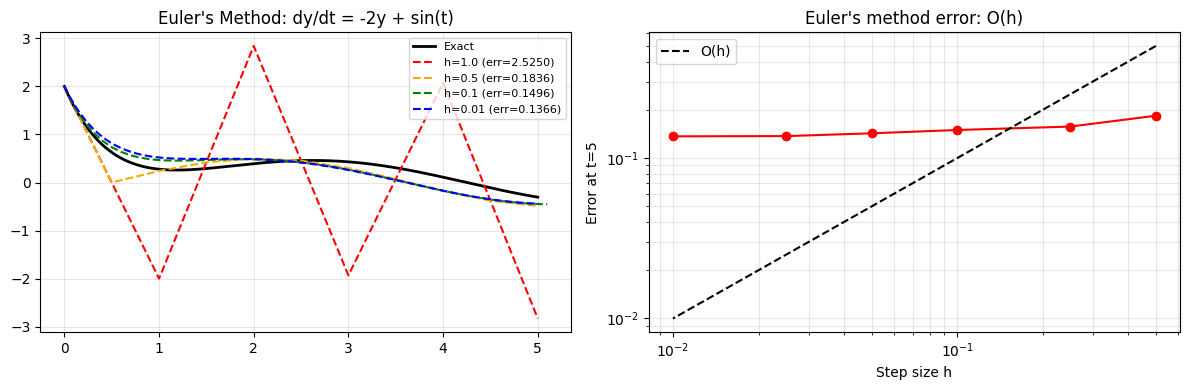

In [2]:
def euler(f, t0, y0, t_end, h):
    ts = [t0]
    ys = [y0]
    while ts[-1] < t_end:
        t, y = ts[-1], ys[-1]
        ts.append(t + h)
        ys.append(y + h * f(t, y))
    return np.array(ts), np.array(ys)

# ODE: dy/dt = -2y + sin(t)
def rhs(t, y): return -2*y + np.sin(t)

# Exact solution (variation of parameters)
def exact(t): return (np.sin(t) - 2*np.cos(t)) / 5 + 2.4 * np.exp(-2*t)

t_fine = np.linspace(0, 5, 500)
y_exact = exact(t_fine)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(t_fine, y_exact, 'k', lw=2, label='Exact')
for h, color in [(1.0, 'red'), (0.5, 'orange'), (0.1, 'green'), (0.01, 'blue')]:
    ts, ys = euler(rhs, 0, exact(0), 5, h)
    err = abs(ys[-1] - exact(5))
    axes[0].plot(ts, ys, '--', color=color, lw=1.5, label=f'h={h} (err={err:.4f})')
axes[0].set_title("Euler's Method: dy/dt = -2y + sin(t)")
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

# Error vs step size (should be O(h))
hs = [0.5, 0.25, 0.1, 0.05, 0.025, 0.01]
errors = []
for h in hs:
    _, ys = euler(rhs, 0, exact(0), 5, h)
    errors.append(abs(ys[-1] - exact(5)))
axes[1].loglog(hs, errors, 'ro-')
axes[1].loglog(hs, np.array(hs), 'k--', label='O(h)')
axes[1].set_xlabel('Step size h'); axes[1].set_ylabel('Error at t=5')
axes[1].set_title("Euler's method error: O(h)"); axes[1].legend(); axes[1].grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.savefig('ch225_euler.png', dpi=100); plt.show()


## Runge-Kutta 4 — Production-Quality ODE Solving

RK4 evaluates the derivative 4 times per step, achieving O(h^4) accuracy at modest cost. Scipy's `solve_ivp` uses an adaptive variant by default.

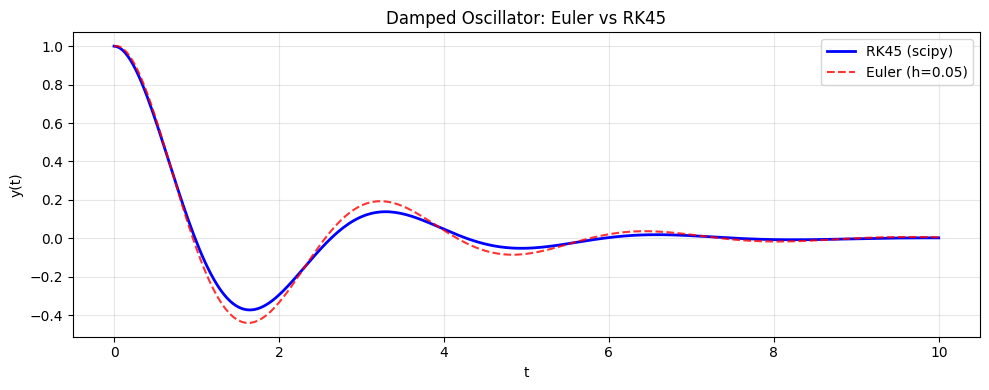

RK45 used 326 function evaluations


In [3]:
# Compare Euler vs RK45 (scipy) on a stiff-ish ODE
def rhs_sys(t, y):
    # Damped oscillator: y'' + 2*zeta*omega*y' + omega^2*y = 0
    # Written as system: [y, v] -> [v, -2*zeta*omega*v - omega^2*y]
    omega, zeta = 2.0, 0.3
    return [y[1], -2*zeta*omega*y[1] - omega**2*y[0]]

y0 = [1.0, 0.0]  # start at rest, displaced
t_span = (0, 10)
t_eval = np.linspace(0, 10, 300)

sol = solve_ivp(rhs_sys, t_span, y0, method='RK45', t_eval=t_eval, rtol=1e-8)

# Euler for comparison
ts_euler, ys_euler = [0], [np.array(y0)]
h_euler = 0.05
while ts_euler[-1] < 10:
    t, y = ts_euler[-1], ys_euler[-1]
    ts_euler.append(t + h_euler)
    ys_euler.append(y + h_euler * np.array(rhs_sys(t, y)))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(sol.t, sol.y[0], 'b', lw=2, label='RK45 (scipy)')
ys_arr = np.array(ys_euler)
ax.plot(ts_euler, ys_arr[:, 0], 'r--', lw=1.5, label=f'Euler (h={h_euler})', alpha=0.8)
ax.set_xlabel('t'); ax.set_ylabel('y(t)')
ax.set_title('Damped Oscillator: Euler vs RK45')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('ch225_rk45.png', dpi=100); plt.show()
print(f"RK45 used {sol.nfev} function evaluations")


## Summary

| Concept | Key Idea |
|---|---|
| ODE | Equation relating a function to its derivatives |
| Euler method | First-order forward stepping: O(h) error |
| RK4 | Four-stage method: O(h^4) error |
| solve_ivp | Scipy adaptive solver — use for production |
| Stiffness | When fast/slow scales coexist — requires implicit solvers |

**Forward reference:** ch226 — Simulation of Differential Systems applies ODE solvers to predator-prey, epidemic, and physical systems.